In [100]:
from utils.dd_startup_functions import *
from utils.new_custom_classes import ParameterField
from utils.sigmav_functions import *
import numpy as np
import matplotlib.pyplot as plt
import itertools
import plotly.graph_objects as go
from tqdm import tqdm
from scipy.integrate import solve_ivp

import pandas as pd
import seaborn as sns

# Parametrization points

In [101]:
# generic number of values for each parameter used for the parametric analysis
param_points = 1

# OPTIONAL - if not specified, the time necessary to reach a 50%D-50%T concentration in the plasma will be calculated
# total time for the parametric analysis [s]
total_time = 10* u.yr

# Parameters

### Plasma parameters

In [102]:
V_plasma_field = ParameterField(
    parametrization_type="normal", mean=150, std=15, unit=u.m**3, 
    param_points=1, name="plasma_volume"
)

T_i_field = ParameterField(
    parametrization_type="linear", min_val=23.3370792, max_val=23.3370792, unit=u.keV,
    param_points=1, name="T_i_field"
)

n_tot_field = ParameterField(
    parametrization_type="linear", min_val=8.11389906e+20, max_val=8.11389906e+20, unit=u.m**(-3),
    param_points=1, name="n_tot_field"
)

tau_p_T_field = ParameterField(
    parametrization_type="linear", min_val = 1, max_val=1, unit=u.s,
    param_points=1, name="tau_p_T"
)

tau_p_He3_field = ParameterField(
    parametrization_type="normal", mean=1, std=0.5, unit=u.s,
    param_points=1, name="tau_p_He3"
)

P_aux_field = ParameterField(
    parametrization_type="linear", min_val=100, max_val=100, unit=u.MW,
    param_points=1, name="P_aux"
)

P_lost_rad_field = ParameterField(
    parametrization_type="linear", min_val=0, max_val=0, unit=u.MW,
    param_points=1, name="P_lost_rad"
)

P_aux_all_DT_field = ParameterField(
    parametrization_type="linear", min_val=100, max_val=100, unit=u.MW,
    param_points=1, name="P_aux"
)

P_lost_rad_all_DT_field = ParameterField(
    parametrization_type="linear", min_val=0, max_val=0, unit=u.MW,
    param_points=1, name="P_lost_rad"
)

print("Plasma parameter fields:")
print(f"V_plasma: {V_plasma_field}")
print(f"T_i_field: {T_i_field}")
print(f"n_tot_field: {n_tot_field}")
print(f"tau_p_T: {tau_p_T_field}")
print(f"tau_p_He3: {tau_p_He3_field}")
print(f"P_aux: {P_aux_field}")
print(f"P_aux_all_DT: {P_aux_all_DT_field}")
print(f"P_lost_rad: {P_lost_rad_field}")
print(f"P_lost_rad_all_DT: {P_lost_rad_all_DT_field}")

TBR_DT_field = ParameterField(
    parametrization_type="linear", min_val=1.09189916, max_val=1.09189916,
    param_points=1, name="TBR_DT"
)

TBR_DDn_field = ParameterField(
    parametrization_type="linear", min_val=0.667229696, max_val=0.667229696,
    param_points=1, name="TBR_DDn"
)

tau_ifc_field = ParameterField(
    parametrization_type="linear", min_val=12, max_val=12, unit=u.h,
    param_points=1, name="tau_ifc"
)

tau_ofc_field = ParameterField(
    parametrization_type="linear", min_val=24, max_val=24, unit=u.h,
    param_points=1, name="tau_ofc"
)

print("Breeding parameters:")
print(f"TBR_DT: {TBR_DT_field}")
print(f"TBR_DDn: {TBR_DDn_field}")
print(f"tau_ifc: {tau_ifc_field}")
print(f"tau_ofc: {tau_ofc_field}")

# Economic parameters
eta_th_field = ParameterField(
    parametrization_type="linear", min_val=0.3, max_val=0.3,
    param_points=1, name="eta_th"
)

plant_avail_field = ParameterField(
    parametrization_type="linear", min_val=0.7, max_val=0.7,
    param_points=1, name="plant_availability"
)

Cost_per_kWh_field = ParameterField(
    parametrization_type="normal", mean=1.59589145e-01, std=1.59589145e-01, unit=1/u.kWh,
    param_points=1, name="Cost_per_kWh"
)

print("Economic parameters:")
print(f"eta_th: {eta_th_field}")
print(f"plant_avail: {plant_avail_field}")
print(f"Cost_per_kWh: {Cost_per_kWh_field}")

Plasma parameter fields:
V_plasma: <ParameterField 'plasma_volume' type=normal, profile=none, shape=(1,), unit=meter ** 3>
[150.000] meter ** 3
T_i_field: <ParameterField 'T_i_field' type=linear, profile=none, shape=(1,), unit=kiloelectron_volt>
[23.337] kiloelectron_volt
n_tot_field: <ParameterField 'n_tot_field' type=linear, profile=none, shape=(1,), unit=1 / meter ** 3>
[811389906000000057344.000] 1 / meter ** 3
tau_p_T: <ParameterField 'tau_p_T' type=linear, profile=none, shape=(1,), unit=second>
[1.000] second
tau_p_He3: <ParameterField 'tau_p_He3' type=normal, profile=none, shape=(1,), unit=second>
[1.000] second
P_aux: <ParameterField 'P_aux' type=linear, profile=none, shape=(1,), unit=megawatt>
[100.000] megawatt
P_aux_all_DT: <ParameterField 'P_aux' type=linear, profile=none, shape=(1,), unit=megawatt>
[100.000] megawatt
P_lost_rad: <ParameterField 'P_lost_rad' type=linear, profile=none, shape=(1,), unit=megawatt>
[0.000] megawatt
P_lost_rad_all_DT: <ParameterField 'P_lost_rad

# Perform the parametric analysis

In [103]:
input_data = [
    V_plasma_field.data,
    T_i_field.data,
    n_tot_field.data,
    tau_p_T_field.data, 
    tau_p_He3_field.data,
    P_aux_field.data,
    P_lost_rad_field.data,
    P_aux_all_DT_field.data,
    P_lost_rad_all_DT_field.data,
        
    TBR_DT_field.data,
    TBR_DDn_field.data,
    tau_ifc_field.data,
    tau_ofc_field.data,
    
    eta_th_field.data,
    plant_avail_field.data,
    Cost_per_kWh_field.data,
]
# Create iterator based only on the number of parameter variations (first dimension)
param_ranges = [range(data.shape[0]) for data in input_data]

print(f"Total number of parameter combinations: {np.prod([len(r) for r in param_ranges])}")
# print estimated time to run (with 2 iterations/s)
print(f"Estimated time to perform the analysis: {np.prod([len(r) for r in param_ranges])/(1.5*3600)} hours (assuming 1.5it/s)")

Total number of parameter combinations: 1
Estimated time to perform the analysis: 0.00018518518518518518 hours (assuming 1.5it/s)


# inventory ode system

In [104]:
results = []
    
def DT_reached(t, y):
    n_T = y[3]/u.m**3
    # Stop when total tritium reaches 50% of total inventory
    return (n_T.to('1/m^3') - 0.5 * n_tot.to('1/m^3')).magnitude

def NEGATIVE(t, y):
    # stop when y[0] or y[1] or y[2] or y[3] is negative
    return min(y[0]+100, y[1]+100, y[2]+100, y[3]+100)


# Time span
t_span = (0, total_time.to('s').magnitude)
t_eval = np.linspace(*t_span, 1000)
    
for param_combo in tqdm(itertools.product(*param_ranges), 
                       total=np.prod([data.shape[0] for data in input_data]), 
                       desc="Parametric analysis"):
    
    # Extract data for each parameter
    extracted_data = [input_data[i][param_idx] for i, param_idx in enumerate(param_combo)]
        
    # Unpack the extracted data
    (V_plasma, T_i, n_tot,
     tau_p_T, tau_p_He3, 
     P_aux, P_lost_rad, P_aux_all_DT, P_lost_rad_all_DT,
     
     TBR_DT, TBR_DDn, tau_ifc, tau_ofc,
     
     eta_th, plant_avail, Cost_per_kWh,
     ) = extracted_data


    # Get cross-sections
    sigmav_DD = sigmav_DD_BoschHale(T_i)[0].to('m^3/s')  # [m^3/s]
    sigmav_DD_p = sigmav_DD_BoschHale(T_i)[1].to('m^3/s')  # [m^3/s]
    sigmav_DD_n = sigmav_DD_BoschHale(T_i)[2].to('m^3/s')  # [m^3/s]
    sigmav_DT = sigmav_DT_BoschHale(T_i).to('m^3/s')    # [m^3/s]
    sigmav_DHe3 = sigmav_DHe3_BoschHale(T_i).to('m^3/s')   # [m^3/s]
    
    y0 = np.zeros(4)  # Initial conditions: [N_ofc, N_ifc, N_st, n_T]

    # stop whe  DT reached
    DT_reached.terminal = True
    NEGATIVE.terminal = True
    
    N_st_min = 0.001/tritium_mass.to('kg').magnitude
    # maximum injection rate is the injection rate necessary to maintain a 50D50T plasma
    injection_rate_max = (n_tot/2/tau_p_T*V_plasma + 0.25*n_tot**2*sigmav_DT*V_plasma - 0.25/2*n_tot**2*sigmav_DD_p*V_plasma).to('1/s')
    
    def tritium_inventory_odes(t,y):
        N_ofc = y[0] # total number of tritium atoms in the outer fuel cycle
        N_ifc = y[1] # total number of tritium atoms in the inner fuel cycle
        N_st = y[2]  # total number of tritium atoms in the storage
        n_T = y[3]  # total tritium density in the plasma (float)
        
        n_T = n_T/u.m**3
        
        # Single spatial point - no integration needed
        n_D = max(n_tot - n_T,0/u.m**3)
        Tdot_DDn = max((TBR_DDn*0.5*n_D**2*sigmav_DD_n*V_plasma),0/u.s).to('1/s')
        Tdot_DDp = max((0.5*n_D**2*sigmav_DD_p*V_plasma),0/u.s).to('1/s')
        Tdot_DT = max((TBR_DT*n_D*n_T*sigmav_DT*V_plasma),0/u.s).to('1/s')
        Tdot_burn = (max(n_D*n_T*sigmav_DT*V_plasma, 0/u.s)).to('1/s')
        
        if N_st < N_st_min:
            # if the inventory in the storage is below the minimum, do not inject
            injection_rate = 0 * u.s**(-1)
        else:
            # tries to inject all the T that enters the storage, limit to injection_rate_max
            injection_rate = min((N_ifc/tau_ifc - lambda_T*N_st), injection_rate_max).to('1/s')

        dN_ofc_dt = (Tdot_DT + Tdot_DDn - N_ofc / tau_ofc - N_ofc*lambda_T).to('1/s')
        dN_ifc_dt = (N_ofc / tau_ofc - N_ifc / tau_ifc  - lambda_T * N_ifc + n_T/tau_p_T*V_plasma).to('1/s')
        dN_stor_dt = (N_ifc / tau_ifc - lambda_T * N_st - injection_rate).to('1/s')
        dnT_dt = (injection_rate/V_plasma + Tdot_DDp/V_plasma - n_T/tau_p_T - Tdot_burn/V_plasma).to('1/s/m^3')
        
        total_T_produced = (Tdot_DDn + Tdot_DDp + Tdot_DT).to('1/s')
        total_T_burnt = (n_D*n_T*sigmav_DT*V_plasma).to('1/s')

        net_T_produced = total_T_produced - total_T_burnt
        return [float(dN_ofc_dt.to('1/s').magnitude), float(dN_ifc_dt.to('1/s').magnitude), float(dN_stor_dt.to('1/s').magnitude), float(dnT_dt.to('1/s/m^3').magnitude)]

    # solve system of ODEs
    sol = solve_ivp(
        fun = tritium_inventory_odes, 
        t_span = t_span, 
        t_eval = t_eval,
        y0 = y0, 
        method = 'BDF', 
        dense_output=False,
        events = [DT_reached, NEGATIVE], )
    
    # identify t_startup
    if sol.t_events[1].size > 0:
        print(f"Negative event occurred at t={sol.t_events[1]}")
        # Create row with inf/None values for failed cases
        row = [
            # INPUTS (still valid)
            V_plasma.to('m^3'),                     # 0
            tau_p_T.to('s'),                        # 1
            tau_p_He3.to('s'),                      # 2
            P_aux.to('MW'),                         # 3
            P_aux_all_DT.to('MW'),                  # 4
            P_lost_rad.to('MW'),                    # 5
            P_lost_rad_all_DT.to('MW'),             # 6
            T_i.to('keV'),                          # 7
            n_tot.to('m^-3'),                       # 8
            TBR_DT,                                 # 9
            TBR_DDn,                                # 10
            tau_ifc.to('h'),                        # 11
            tau_ofc.to('h'),                        # 12
            eta_th,                                 # 13
            plant_avail,                            # 14
            Cost_per_kWh.to('1/kWh'),               # 15
            # OUTPUTS (failed values)
            sigmav_DT.to('m^3/s'),                  # 16
            sigmav_DD_n.to('m^3/s'),                # 17
            sigmav_DD_p.to('m^3/s'),                # 18
            sigmav_DHe3.to('m^3/s'),                # 19
            np.inf,                                 # 20 - P_DT
            np.inf,                                 # 21 - P_DDn
            np.inf,                                 # 22 - P_DDp
            np.inf,                                 # 23 - P_DT_full
            np.inf,                                 # 24 - P_e_net_DD_avg
            np.inf,                                 # 25 - Q_DD_total
            np.inf,                                 # 26 - P_e_net_DT_full_avg
            np.inf,                                 # 27 - Q_DT_full_total
            np.inf,                                 # 28 - E_e_net_DD
            np.inf,                                 # 29 - E_e_net_DT_full
            np.inf,                                 # 30 - t_startup
            np.inf,                                 # 31 - E_lost
            np.inf,                                 # 32 - Dollar_Lost
            None,                                   # 33 - n_T
            None,                                   # 34 - I_ifc
            None,                                   # 35 - I_ofc
            None                                    # 36 - I_stor
        ]
        results.append(row)
        continue
    elif sol.t_events[0].size > 0:
        t_startup = sol.t_events[0][0]*u.s
    else:
        t_startup = np.inf*u.s
        
    n_T = sol.y[3] * u.m**(-3)  # shape (n_spatial, n_time)
    n_D = n_tot - n_T
    
    # evolution of fusion power
    P_DDn = n_D*n_D*sigmav_DD_n/2*V_plasma*E_DDn
    P_DDp = n_D*n_D*sigmav_DD_p/2*V_plasma*E_DDp
    P_DT = n_D*n_T*sigmav_DT*V_plasma*E_DT
    # equivalent energy if always DT
    P_DT_full = n_tot/2*n_tot/2*sigmav_DT*V_plasma*E_DT
    # Calculate energies properly - similar to main.py approach
    t_end = t_startup.to('s').magnitude if np.isfinite(t_startup.to('s').magnitude) else total_time.to('s').magnitude
    mask = sol.t <= t_end
    t_end = t_end*u.s
    # Total fusion energies by integration (variable powers)
    E_fusion_DDn = np.trapz(P_DDn[mask], sol.t[mask])*u.s
    E_fusion_DDp = np.trapz(P_DDp[mask], sol.t[mask]) *u.s
    E_fusion_DT = np.trapz(P_DT[mask], sol.t[mask])*u.s
    E_fusion_total_DD = E_fusion_DDn + E_fusion_DDp + E_fusion_DT

    # Reference energy if always DT (constant power * time)
    E_fusion_DT_full = P_DT_full * t_end

    # Total auxiliary energies (constant power * time)  
    E_aux_DD = P_aux * t_end
    E_aux_DT_full = P_aux_all_DT * t_end

    # Total radiation losses (constant power * time)
    E_rad_DD = P_lost_rad * t_end
    E_rad_DT_full = P_lost_rad_all_DT * t_end

    # Net electrical energies (with thermal efficiency and plant availability)
    E_e_net_DD = plant_avail * (eta_th * (E_fusion_total_DD - E_rad_DD) - E_aux_DD)
    E_e_net_DT_full = plant_avail * (eta_th * (E_fusion_DT_full - E_rad_DT_full) - E_aux_DT_full)

    # Q factors based on total energy
    Q_DD_total = E_fusion_total_DD / E_aux_DD if E_aux_DD > 0 else np.inf
    Q_DT_full_total = E_fusion_DT_full / E_aux_DT_full if E_aux_DT_full > 0 else np.inf

    # Average powers for reference (divide total energy by time)
    time_duration = t_end if t_end > 0 else 1.0  # Avoid division by zero
    P_fusion_DD_avg = E_fusion_total_DD / time_duration 
    P_e_net_DD_avg = E_e_net_DD / time_duration
    P_e_net_DT_full_avg = E_e_net_DT_full / time_duration

    # Energy lost (opportunity cost)
    E_lost = E_e_net_DT_full - E_e_net_DD
    Dollar_Lost = E_lost * Cost_per_kWh

    n_T = sol.y[3] * u.m**(-3)
    I_ifc = sol.y[0] * tritium_mass.to('kg')
    I_ofc = sol.y[1] * tritium_mass.to('kg')
    I_stor = sol.y[2] * tritium_mass.to('kg')
    
    row = [
        # INPUTS
        V_plasma.to('m^3'),                     # 0
        tau_p_T.to('s'),                        # 1
        tau_p_He3.to('s'),                      # 2
        P_aux.to('MW'),                         # 3
        P_aux_all_DT.to('MW'),                  # 4
        P_lost_rad.to('MW'),                    # 5
        P_lost_rad_all_DT.to('MW'),             # 6
        T_i.to('keV'),                          # 7
        n_tot.to('m^-3'),                       # 8
        #injection_rate_max,                    # -
        TBR_DT,                                 # 9
        TBR_DDn,                                # 10
        tau_ifc,                                # 11
        tau_ofc,                                # 12
        eta_th,                                 # 13
        plant_avail,                            # 14
        Cost_per_kWh.to('1/kWh'),               # 15
        # OUTPUTS
        sigmav_DT.to('m^3/s'),                  # 16
        sigmav_DD_n.to('m^3/s'),                # 17
        sigmav_DD_p.to('m^3/s'),                # 18
        sigmav_DHe3.to('m^3/s'),                # 19
        P_DT.to('MW'),                          # 20
        P_DDn.to('MW'),                         # 21
        P_DDp.to('MW'),                         # 22
        P_DT_full.to('MW'),                     # 23
        P_e_net_DD_avg,                    # 24
        Q_DD_total,               # 25
        P_e_net_DT_full_avg,               # 26
        Q_DT_full_total,          # 27
        E_e_net_DD.to('MJ'),                    # 28
        E_e_net_DT_full.to('MJ'),               # 29
        t_startup.to('hour'),                   # 30
        E_lost.to('MJ'),                        # 31
        Dollar_Lost.to(''),                     # 32
        n_T,                                    # 33
        I_ifc,                                  # 34
        I_ofc,                                  # 35
        I_stor                                  # 36
    ]
    results.append(row)

Parametric analysis:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_224415/2813323856.py:161: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_fusion_DDn = np.trapz(P_DDn[mask], sol.t[mask])*u.s
/tmp/ipykernel_224415/2813323856.py:162: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_fusion_DDp = np.trapz(P_DDp[mask], sol.t[mask]) *u.s
/tmp/ipykernel_224415/2813323856.py:163: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_fusion_DT = np.trapz(P_DT[mask], sol.t[mask])*u.s
Parametric analysis: 100%|██████████| 1/1 [00:01<00:00,  1.14s/it]


In [105]:
print("Parametric analysis completed.")
#column names
columns = [
    # INPUTS
    "V_plasma (m^3)",                     # 0
    "tau_p_T (s)",                        # 1
    "tau_p_He3 (s)",                      # 2
    "P_aux (MW)",                         # 3
    "P_aux_all_DT (MW)",                  # 4
    "P_lost_rad (MW)",                    # 5
    "P_lost_rad_all_DT (MW)",             # 6
    "T_i (keV)",                          # 7
    "n_tot (m^-3)",                       # 8
    #"injection_rate_max",                # -
    "TBR_DT",                             # 9
    "TBR_DDn",                            # 10
    "tau_ifc (h)",                        # 11
    "tau_ofc (h)",                        # 12
    "eta_th",                             # 13
    "plant_availability",                 # 14
    "Cost_per_kWh (1/kWh)",               # 15
    # OUTPUTS
    "sigmav_DT (m^3/s)",                  # 16
    "sigmav_DD_n (m^3/s)",                # 17
    "sigmav_DD_p (m^3/s)",                # 18
    "sigmav_DHe3 (m^3/s)",                # 19
    "P_DT (MW)",                          # 20
    "P_DDn (MW)",                         # 21
    "P_DDp (MW)",                         # 22
    "P_DT_full (MW)",                     # 23
    "P_e_net_DD (MW)",                    # 24
    "Q_DD",                               # 25
    "P_e_net_DT_full (MW)",               # 26
    "Q_DT_full",                          # 27
    "E_e_net_DD (MJ)",                    # 28
    "E_e_net_DT_full (MJ)",               # 29
    "t_startup (h)",                      # 30
    "E_lost (MJ)",                        # 31
    "Dollar_Lost ($)",                    # 32
    "n_T (m^-3)",                         # 33
    "I_ifc (kg)",                         # 34
    "I_ofc (kg)",                         # 35
    "I_stor (kg)"                         # 36
]

# print results with name of each column
for i, col in enumerate(columns):
    print(f"{col}: {results[0][i]}")

Parametric analysis completed.
V_plasma (m^3): 150 meter ** 3
tau_p_T (s): 1.0 second
tau_p_He3 (s): 1 second
P_aux (MW): 100.0 megawatt
P_aux_all_DT (MW): 100.0 megawatt
P_lost_rad (MW): 0.0 megawatt
P_lost_rad_all_DT (MW): 0.0 megawatt
T_i (keV): 23.3370792 kiloelectron_volt
n_tot (m^-3): 8.11389906e+20 / meter ** 3
TBR_DT: 1.09189916 dimensionless
TBR_DDn: 0.667229696 dimensionless
tau_ifc (h): 12.0 hour
tau_ofc (h): 24.0 hour
eta_th: 0.3 dimensionless
plant_availability: 0.7 dimensionless
Cost_per_kWh (1/kWh): 0.159589145 / kilowatt_hour
sigmav_DT (m^3/s): 5.246911389632226e-22 meter ** 3 / second
sigmav_DD_n (m^3/s): 3.444190339069795e-24 meter ** 3 / second
sigmav_DD_p (m^3/s): 3.1413611742231543e-24 meter ** 3 / second
sigmav_DHe3 (m^3/s): 5.9886091043980385e-24 meter ** 3 / second
P_DT (MW): [0.0 1141.882906634263 2328.1439175865003 3637.46465728531 5078.832621104919 6661.892659360605 8392.458989243709 10279.640380581075 12323.97643648597 14528.95660878823 16889.122260272685 19

Found 7 vector quantities:
  - P_DT (MW)
  - P_DDn (MW)
  - P_DDp (MW)
  - n_T (m^-3)
  - I_ifc (kg)
  - I_ofc (kg)
  - I_stor (kg)


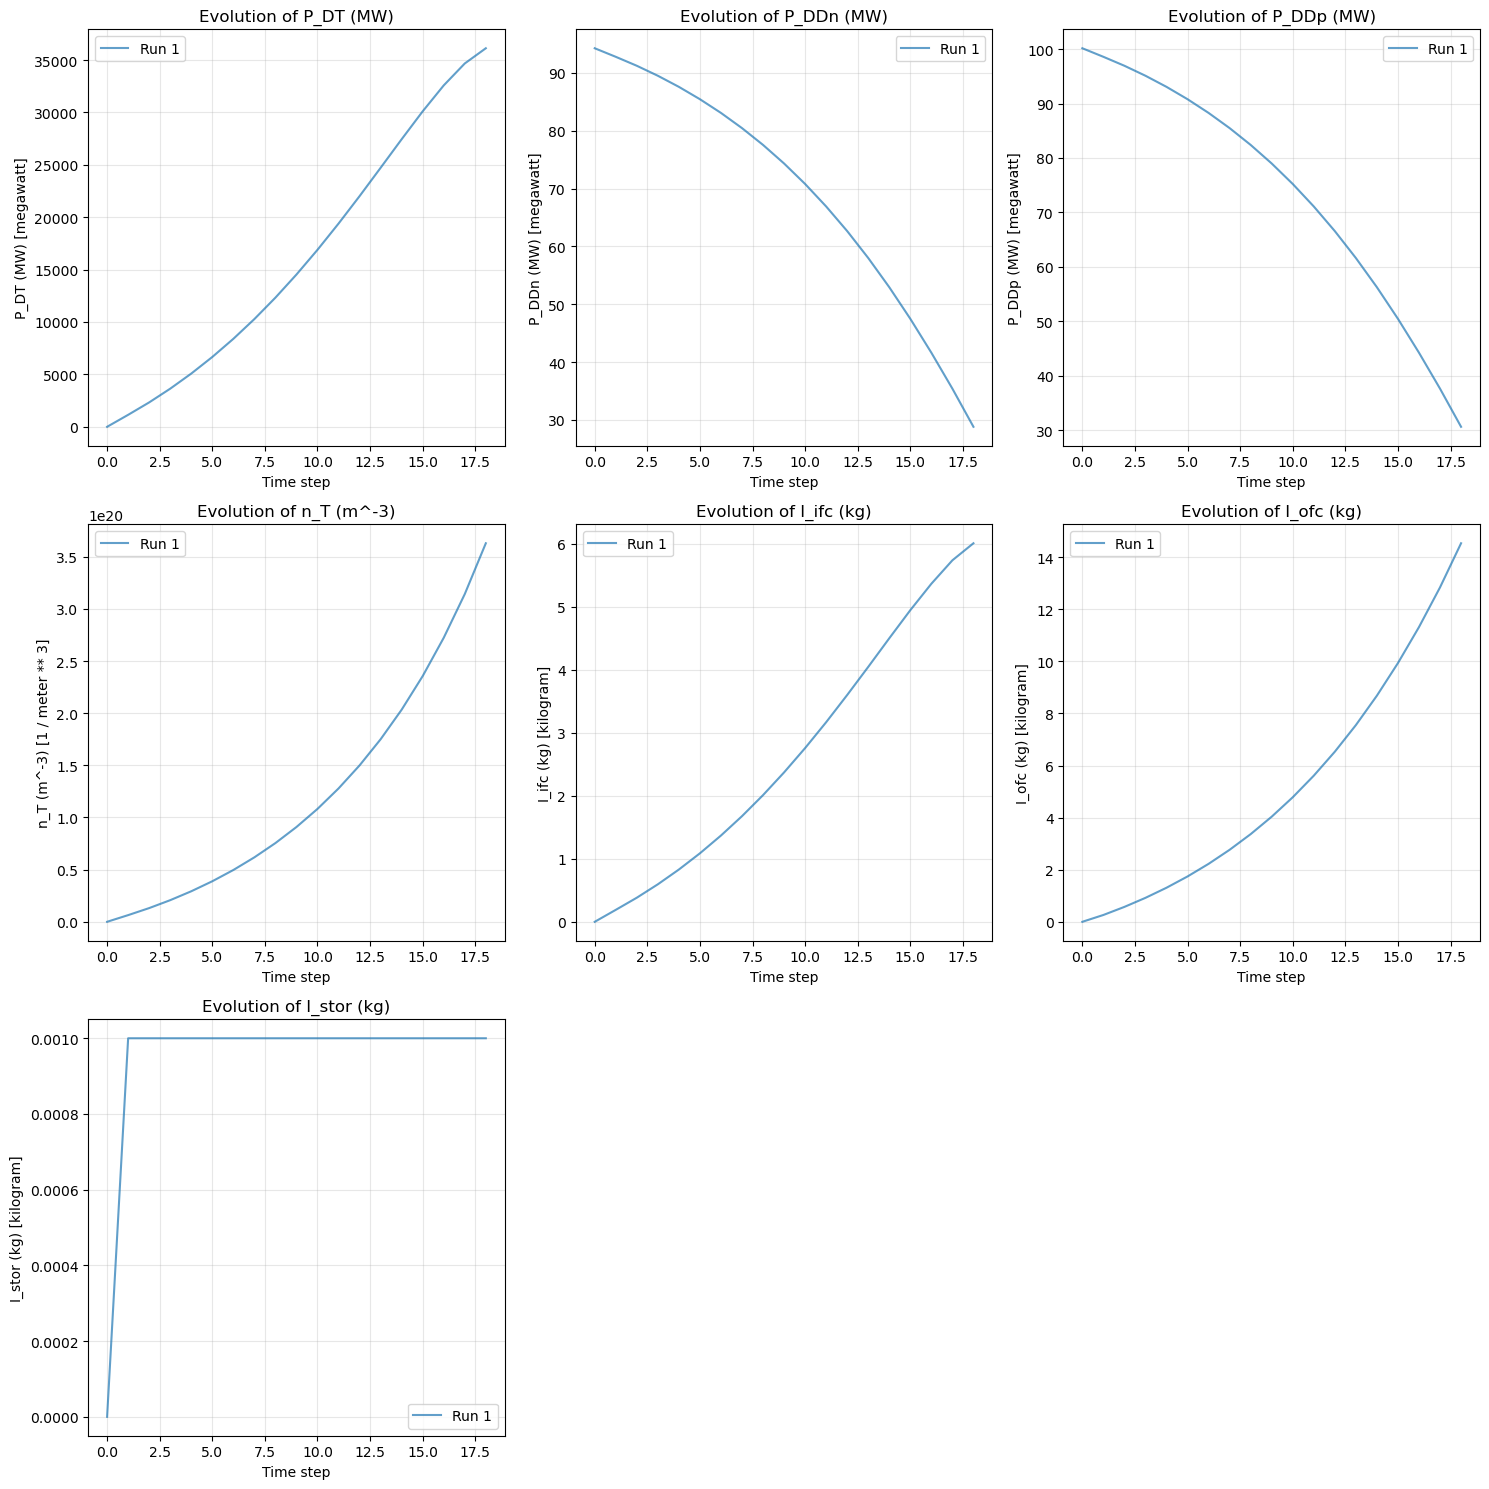


Diagnostic information:
Number of result rows: 1
Number of columns: 37
Sample data types:
  V_plasma (m^3): pint quantity, magnitude type: <class 'numpy.int64'>, shape: ()
  tau_p_T (s): pint quantity, magnitude type: <class 'numpy.float64'>, shape: ()
  tau_p_He3 (s): pint quantity, magnitude type: <class 'numpy.int64'>, shape: ()
  P_aux (MW): pint quantity, magnitude type: <class 'numpy.float64'>, shape: ()
  P_aux_all_DT (MW): pint quantity, magnitude type: <class 'numpy.float64'>, shape: ()
  P_lost_rad (MW): pint quantity, magnitude type: <class 'numpy.float64'>, shape: ()
  P_lost_rad_all_DT (MW): pint quantity, magnitude type: <class 'numpy.float64'>, shape: ()
  T_i (keV): pint quantity, magnitude type: <class 'numpy.float64'>, shape: ()
  n_tot (m^-3): pint quantity, magnitude type: <class 'numpy.float64'>, shape: ()
  TBR_DT: pint quantity, magnitude type: <class 'numpy.float64'>, shape: ()


In [106]:
# Plot evolution of all vector quantities in results
import matplotlib.pyplot as plt
import numpy as np

# First, identify which columns contain vectors
vector_columns = []
vector_indices = []

for i, col in enumerate(columns):
    if len(results) > 0 and results[0][i] is not None:
        # Handle pint quantities
        if hasattr(results[0][i], 'magnitude'):
            # It's a pint quantity, check if the magnitude is an array
            if isinstance(results[0][i].magnitude, np.ndarray):
                vector_columns.append(col)
                vector_indices.append(i)
        elif isinstance(results[0][i], np.ndarray):
            # It's a regular numpy array
            vector_columns.append(col)
            vector_indices.append(i)

print(f"Found {len(vector_columns)} vector quantities:")
for col in vector_columns:
    print(f"  - {col}")

if len(vector_columns) > 0:
    # Create subplots
    n_plots = len(vector_columns)
    n_cols = min(3, n_plots)  # Max 3 columns
    n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    
    # Handle case where we only have one subplot
    if n_plots == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Flatten axes array for easier indexing
    axes_flat = axes.flatten() if n_plots > 1 else axes
    
    for plot_idx, (col_idx, col_name) in enumerate(zip(vector_indices, vector_columns)):
        ax = axes_flat[plot_idx]
        
        # Plot data for each run
        for j, row in enumerate(results):
            data = row[col_idx]
            
            if data is not None:
                # Handle pint quantities
                if hasattr(data, 'magnitude'):
                    y_data = data.magnitude
                    units = str(data.units) if hasattr(data, 'units') else ''
                    ylabel = f"{col_name} [{units}]" if units else col_name
                else:
                    y_data = data
                    ylabel = col_name
                
                # Create x-axis (assuming it's time steps)
                x_data = np.arange(len(y_data))
                
                ax.plot(x_data, y_data, label=f"Run {j+1}", alpha=0.7)
        
        ax.set_xlabel("Time step")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Evolution of {col_name}")
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide any unused subplots
    for plot_idx in range(len(vector_columns), len(axes_flat)):
        axes_flat[plot_idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No vector quantities found in results!")

# Also print some diagnostic info
print(f"\nDiagnostic information:")
print(f"Number of result rows: {len(results)}")
if len(results) > 0:
    print(f"Number of columns: {len(results[0])}")
    print(f"Sample data types:")
    for i, col in enumerate(columns[:10]):  # Show first 10
        if results[0][i] is not None:
            data = results[0][i]
            if hasattr(data, 'magnitude'):
                print(f"  {col}: pint quantity, magnitude type: {type(data.magnitude)}, shape: {getattr(data.magnitude, 'shape', 'scalar')}")
            else:
                print(f"  {col}: {type(data)}, shape: {getattr(data, 'shape', 'scalar')}")
        else:
            print(f"  {col}: None")